<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ml6-clustering-and-neural-networks-for-environmental-analysis./blob/main/ml6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path= '/content/drive/MyDrive/Global_Pollution_Analysis.csv'
data= pd.read_csv(path)
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
data.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [5]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [6]:
data.fillna(data.ffill(), inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data['Country']= le.fit_transform(data['Country'])
data

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,92,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [8]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
data['Air_Pollution_Index']= sc.fit_transform(data['Air_Pollution_Index'].values.reshape(-1, 1))
data['Water_Pollution_Index']= sc.fit_transform(data['Water_Pollution_Index'].values.reshape(-1, 1))
data['Soil_Pollution_Index']= sc.fit_transform(data['Soil_Pollution_Index'].values.reshape(-1, 1))
data

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,77,2005,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,147,2001,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,136,2016,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,38,2018,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,46,2008,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,92,2004,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2002,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,2011,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2002,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [9]:
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita (in MWh)'] / data['Population (in millions)']
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Energy_Consumption_Per_Capita
0,77,2005,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489
1,147,2001,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106
2,136,2016,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648
3,38,2018,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504
4,46,2008,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840


In [10]:
yearly_trends = data.groupby('Year')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']].mean()
yearly_trends.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Year,,,,
2000,0.256617,0.072583,-0.181989,296.889000
2001,-0.637654,-0.655996,-0.130036,288.877778
2002,-0.089162,0.180136,-0.028892,259.750769
2003,0.335938,0.379503,0.611174,208.139000
2004,-0.142082,0.119064,-0.164913,186.458182


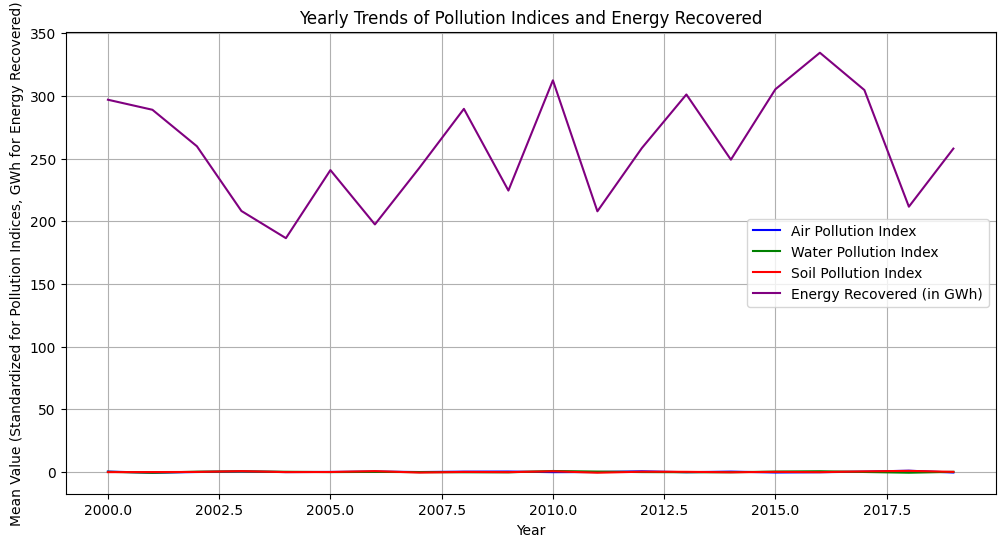

In [11]:
plt.figure(figsize=(12, 6))

# Define colors for each line for better visualization
colors = ['blue', 'green', 'red', 'purple']

# Plot each trend
for i, column in enumerate(yearly_trends.columns):
    if 'Pollution_Index' in column:
        plt.plot(yearly_trends.index, yearly_trends[column], label=column.replace('_', ' '), color=colors[i])
    elif 'Energy_Recovered' in column:
        plt.plot(yearly_trends.index, yearly_trends[column], label=column.replace('_', ' '), color=colors[i])

plt.title('Yearly Trends of Pollution Indices and Energy Recovered')
plt.xlabel('Year')
plt.ylabel('Mean Value (Standardized for Pollution Indices, GWh for Energy Recovered)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
clustering_data = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']]
print("Created clustering_data DataFrame with selected columns:")
print(clustering_data.head())

Created clustering_data DataFrame with selected columns:
   Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
0             1.376167               0.193880             -0.619764   
1            -1.403578              -1.153098              1.028744   
2            -1.330788              -0.668076              1.142400   
3             1.494394              -1.009403              0.431675   
4            -0.021926               0.262567              1.138106   

   Energy_Recovered (in GWh)  
0                     158.14  
1                     498.04  
2                     489.51  
3                     145.18  
4                      40.38  


In [13]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(clustering_data)
    wcss.append(kmeans.inertia_)
print("WCSS calculated for 1 to 10 clusters:")
print(wcss)

WCSS calculated for 1 to 10 clusters:
[4309098.351462002, 999419.2287287718, 435950.5532678915, 218887.7929234411, 154477.046260978, 105104.78538887254, 69584.32621886118, 49932.40822381154, 39507.80176528354, 32963.60004484784]


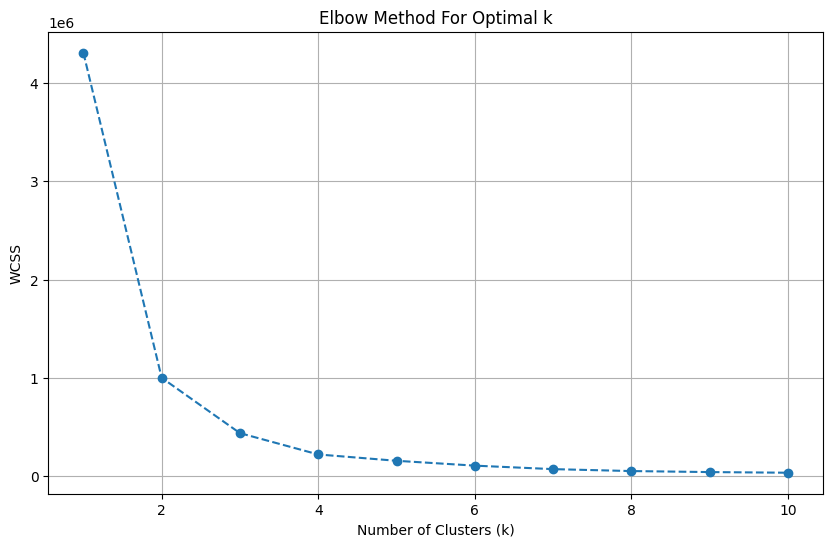

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(clustering_data)
data['Cluster'] = clusters
print("K-Means clustering applied with 3 clusters. New 'Cluster' column added to the data DataFrame.")
print(data.head())

K-Means clustering applied with 3 clusters. New 'Cluster' column added to the data DataFrame.
   Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       77  2005             1.376167               0.193880   
1      147  2001            -1.403578              -1.153098   
2      136  2016            -1.330788              -0.668076   
3       38  2018             1.494394              -1.009403   
4       46  2008            -0.021926               0.262567   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0             -0.619764                    94802.83   
1              1.028744                    56283.92   
2              1.142400                    56256.02   
3              0.431675                    74864.73   
4              1.138106                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04        

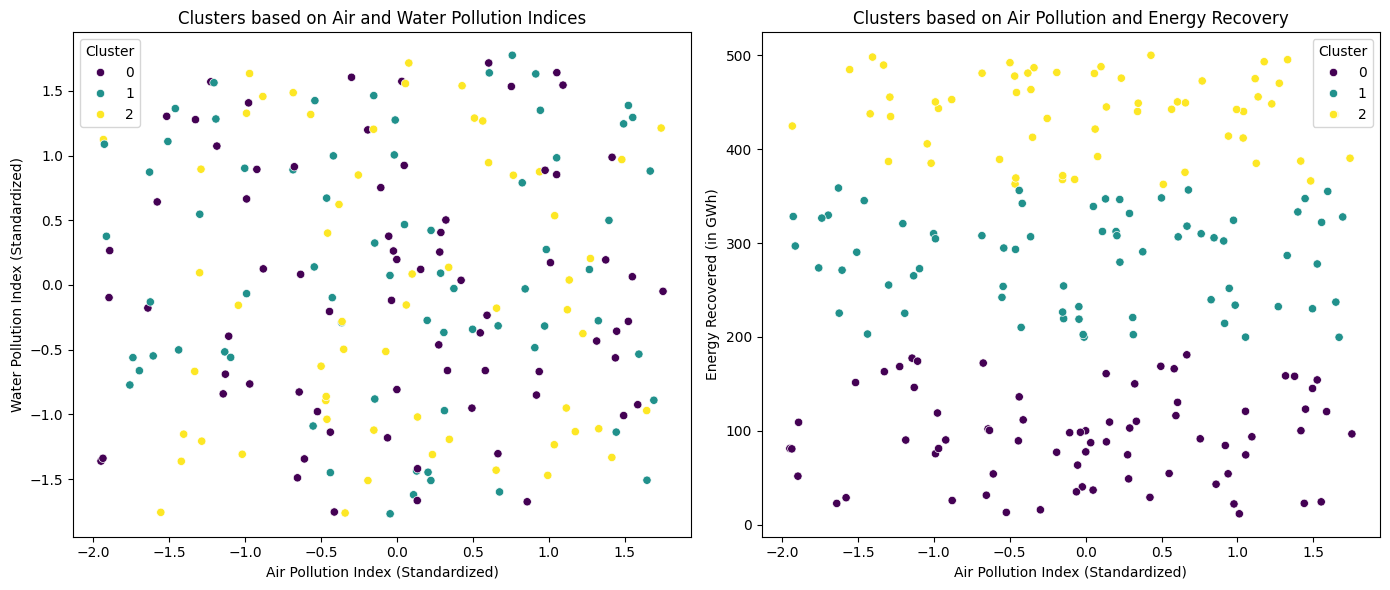

In [16]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=data, x='Air_Pollution_Index', y='Water_Pollution_Index', hue='Cluster', palette='viridis')
plt.title('Clusters based on Air and Water Pollution Indices')
plt.xlabel('Air Pollution Index (Standardized)')
plt.ylabel('Water Pollution Index (Standardized)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(data=data, x='Air_Pollution_Index', y='Energy_Recovered (in GWh)', hue='Cluster', palette='viridis')
plt.title('Clusters based on Air Pollution and Energy Recovery')
plt.xlabel('Air Pollution Index (Standardized)')
plt.ylabel('Energy Recovered (in GWh)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [17]:
print("Sample of countries within each cluster:")
for cluster_id in sorted(data['Cluster'].unique()):
    cluster_countries = data[data['Cluster'] == cluster_id]['Country'].unique()
    print(f"\nCluster {cluster_id}:")
    # Displaying up to 10 unique country IDs for each cluster
    print(cluster_countries[:10])

Sample of countries within each cluster:

Cluster 0:
[ 77  38  46  41 165 123 161  27 145  39]

Cluster 1:
[ 37 100 150 148 125 149 102  73   3 162]

Cluster 2:
[147 136  31 156 153  99  67 103  63   6]


In [18]:
hierarchical_clustering_data = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']]
print("Created hierarchical_clustering_data DataFrame with selected columns:")
print(hierarchical_clustering_data.head())

Created hierarchical_clustering_data DataFrame with selected columns:
   Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
0             1.376167               0.193880             -0.619764   
1            -1.403578              -1.153098              1.028744   
2            -1.330788              -0.668076              1.142400   
3             1.494394              -1.009403              0.431675   
4            -0.021926               0.262567              1.138106   

   Energy_Recovered (in GWh)  
0                     158.14  
1                     498.04  
2                     489.51  
3                     145.18  
4                      40.38  


In [19]:
from scipy.cluster.hierarchy import linkage

linked = linkage(hierarchical_clustering_data, method='ward')
print("Linkage matrix computed using 'ward' method.")
print(f"Shape of linkage matrix: {linked.shape}")

Linkage matrix computed using 'ward' method.
Shape of linkage matrix: (199, 4)


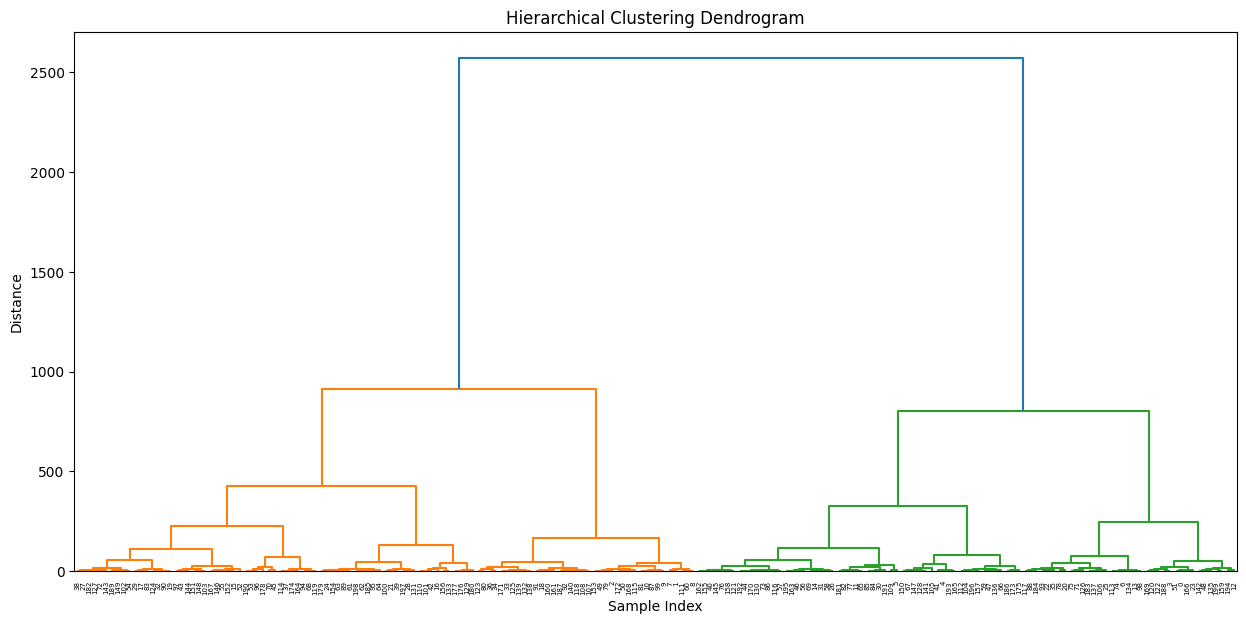

In [20]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hierarchical_clusters = hc.fit_predict(hierarchical_clustering_data)
data['Hierarchical_Cluster'] = hierarchical_clusters
print("Agglomerative Clustering applied with 3 clusters. New 'Hierarchical_Cluster' column added to the data DataFrame.")
print(data.head())

Agglomerative Clustering applied with 3 clusters. New 'Hierarchical_Cluster' column added to the data DataFrame.
   Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       77  2005             1.376167               0.193880   
1      147  2001            -1.403578              -1.153098   
2      136  2016            -1.330788              -0.668076   
3       38  2018             1.494394              -1.009403   
4       46  2008            -0.021926               0.262567   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0             -0.619764                    94802.83   
1              1.028744                    56283.92   
2              1.142400                    56256.02   
3              0.431675                    74864.73   
4              1.138106                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                

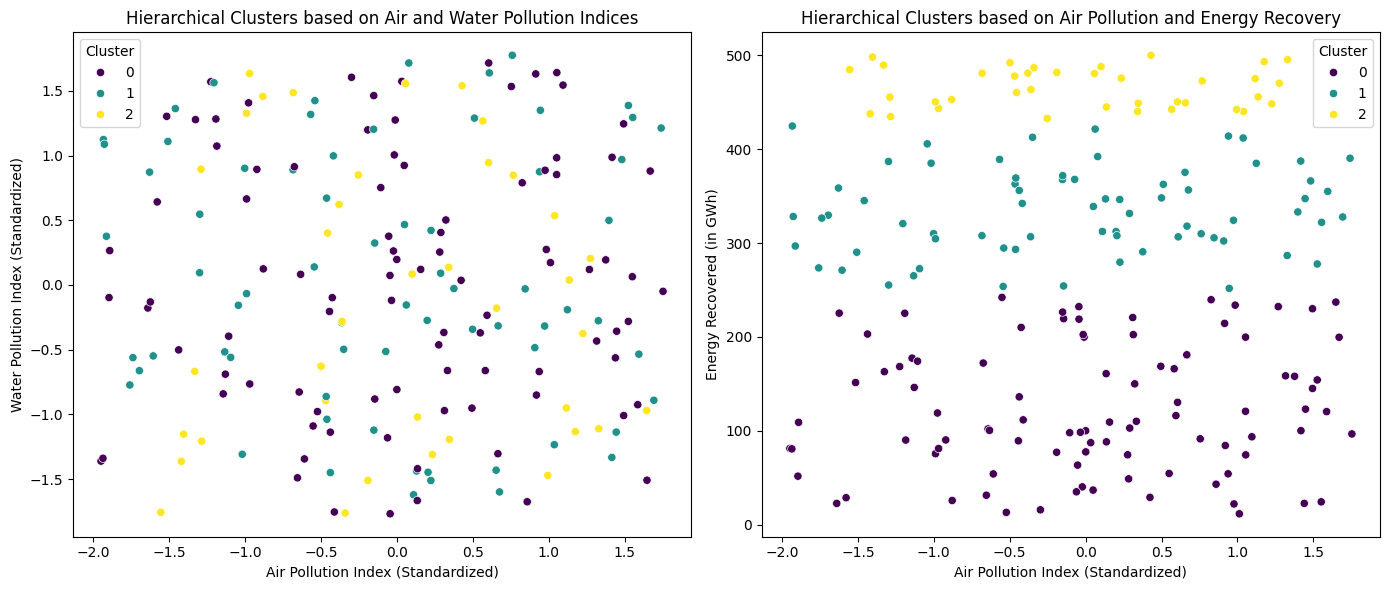

In [22]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=data, x='Air_Pollution_Index', y='Water_Pollution_Index', hue='Hierarchical_Cluster', palette='viridis')
plt.title('Hierarchical Clusters based on Air and Water Pollution Indices')
plt.xlabel('Air Pollution Index (Standardized)')
plt.ylabel('Water Pollution Index (Standardized)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(data=data, x='Air_Pollution_Index', y='Energy_Recovered (in GWh)', hue='Hierarchical_Cluster', palette='viridis')
plt.title('Hierarchical Clusters based on Air Pollution and Energy Recovery')
plt.xlabel('Air Pollution Index (Standardized)')
plt.ylabel('Energy Recovered (in GWh)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

silhouette_avg_kmeans = silhouette_score(clustering_data, clusters)

print(f"Silhouette Score for K-Means Clustering: {silhouette_avg_kmeans:.4f}")

Silhouette Score for K-Means Clustering: 0.6065


In [23]:
print("--- Cluster sizes for K-Means ---")
print(data['Cluster'].value_counts())

print("\n--- Cluster sizes for Hierarchical Clustering ---")
print(data['Hierarchical_Cluster'].value_counts())

clustering_features = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']

print("\n--- Mean feature values for K-Means Clusters ---")
print(data.groupby('Cluster')[clustering_features].mean())

print("\n--- Mean feature values for Hierarchical Clusters ---")
print(data.groupby('Hierarchical_Cluster')[clustering_features].mean())

--- Cluster sizes for K-Means ---
Cluster
0    72
1    69
2    59
Name: count, dtype: int64

--- Cluster sizes for Hierarchical Clustering ---
Hierarchical_Cluster
0    93
1    69
2    38
Name: count, dtype: int64

--- Mean feature values for K-Means Clusters ---
         Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
Cluster                                                                     
0                  -0.007332              -0.028474             -0.096356   
1                  -0.021005               0.104524              0.122942   
2                   0.033513              -0.087492             -0.026192   

         Energy_Recovered (in GWh)  
Cluster                             
0                        94.079028  
1                       282.812754  
2                       437.321525  

--- Mean feature values for Hierarchical Clusters ---
                      Air_Pollution_Index  Water_Pollution_Index  \
Hierarchical_Cluster                      

In [34]:
from sklearn.metrics import silhouette_score

silhouette_avg_hierarchical = silhouette_score(hierarchical_clustering_data, hierarchical_clusters)

print(f"Silhouette Score for Hierarchical Clustering: {silhouette_avg_hierarchical:.4f}")

Silhouette Score for Hierarchical Clustering: 0.5861


In [35]:
print(f"K-Means Silhouette Score: {silhouette_avg_kmeans:.4f}")
print(f"Hierarchical Clustering Silhouette Score: {silhouette_avg_hierarchical:.4f}")

K-Means Silhouette Score: 0.6065
Hierarchical Clustering Silhouette Score: 0.5861


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Define the feature matrix X
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']]

# 2. Define the target variable y
y = data['Energy_Recovered (in GWh)']

# 3. Initialize StandardScaler
scaler = StandardScaler()

# 5. Apply scaling to the unscaled features in X
# Pollution indices are already scaled, so we only scale CO2_Emissions and Industrial_Waste
X['CO2_Emissions (in MT)'] = scaler.fit_transform(X['CO2_Emissions (in MT)'].values.reshape(-1, 1))
X['Industrial_Waste (in tons)'] = scaler.fit_transform(X['Industrial_Waste (in tons)'].values.reshape(-1, 1))

print("Features (X) and target (y) defined.")
print("CO2_Emissions (in MT) and Industrial_Waste (in tons) columns in X have been scaled.")

# 6. Split the scaled X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data split into training and testing sets.")

Features (X) and target (y) defined.
CO2_Emissions (in MT) and Industrial_Waste (in tons) columns in X have been scaled.

Shape of X_train: (160, 5)
Shape of X_test: (40, 5)
Shape of y_train: (160,)
Shape of y_test: (40,)
Data split into training and testing sets.


/tmp/ipykernel_164/3935279175.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['CO2_Emissions (in MT)'] = scaler.fit_transform(X['CO2_Emissions (in MT)'].values.reshape(-1, 1))
/tmp/ipykernel_164/3935279175.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Industrial_Waste (in tons)'] = scaler.fit_transform(X['Industrial_Waste (in tons)'].values.reshape(-1, 1))


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Define the feature matrix X, ensuring it's a copy to avoid SettingWithCopyWarning
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']].copy()

# 2. Define the target variable y
y = data['Energy_Recovered (in GWh)']

# 3. Initialize StandardScaler
scaler = StandardScaler()

# 5. Apply scaling to the unscaled features in X
# Pollution indices are already scaled, so we only scale CO2_Emissions and Industrial_Waste
X['CO2_Emissions (in MT)'] = scaler.fit_transform(X['CO2_Emissions (in MT)'].values.reshape(-1, 1))
X['Industrial_Waste (in tons)'] = scaler.fit_transform(X['Industrial_Waste (in tons)'].values.reshape(-1, 1))

print("Features (X) and target (y) defined.")
print("CO2_Emissions (in MT) and Industrial_Waste (in tons) columns in X have been scaled.")

# 6. Split the scaled X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data split into training and testing sets.")

Features (X) and target (y) defined.
CO2_Emissions (in MT) and Industrial_Waste (in tons) columns in X have been scaled.

Shape of X_train: (160, 5)
Shape of X_test: (40, 5)
Shape of y_train: (160,)
Shape of y_test: (40,)
Data split into training and testing sets.


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Keras models and layers imported successfully.")

Keras models and layers imported successfully.


In [27]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear')) # Output layer for regression

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

print("Neural network model constructed and compiled:")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural network model constructed and compiled:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear')) # Output layer for regression

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

print("Neural network model constructed and compiled:")
model.summary()

Neural network model constructed and compiled:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)
print("Model training complete.")

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 97869.2969 - mean_absolute_error: 276.8500 - val_loss: 77036.5312 - val_mean_absolute_error: 238.1749
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 94081.2031 - mean_absolute_error: 271.8851 - val_loss: 76840.8906 - val_mean_absolute_error: 237.7716
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 88591.8516 - mean_absolute_error: 262.1546 - val_loss: 76601.6875 - val_mean_absolute_error: 237.2743
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 98719.8984 - mean_absolute_error: 278.5607 - val_loss: 76305.9688 - val_mean_absolute_error: 236.6558
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 85788.7266 - mean_absolute_error: 255.3038 - val_loss: 75928.0938 - val_mean_absolute_error: 235.8674
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 90343.2891 - mean_absolute_error: 266.4482 - val_loss: 75441.4609 - val_mean_absolute_error: 234.8541
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [36]:
from sklearn.metrics import r2_score

y_pred_nn = model.predict(X_test)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"R-squared (R²) for Neural Network: {r2_nn:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
R-squared (R²) for Neural Network: -0.0330


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Instantiate Linear Regression model
linear_model = LinearRegression()

# Fit the model to the training data
linear_model.fit(X_train, y_train)
print("Linear Regression model trained.")

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)
print("Predictions made on the test set.")

# Calculate evaluation metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"R-squared (R²): {r2_lr:.4f}")

Linear Regression model trained.
Predictions made on the test set.

Linear Regression Model Performance:
Mean Squared Error (MSE): 24538.0599
Mean Absolute Error (MAE): 141.3460
R-squared (R²): -0.0147


In [32]:
print("\n--- Neural Network Model Performance ---")
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae:.4f}")

print("\n--- Linear Regression Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"R-squared (R²): {r2_lr:.4f}")


--- Neural Network Model Performance ---
Test Loss (MSE): 24981.4434
Test Mean Absolute Error (MAE): 138.3783

--- Linear Regression Model Performance ---
Mean Squared Error (MSE): 24538.0599
Mean Absolute Error (MAE): 141.3460
R-squared (R²): -0.0147


In [30]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Mean Absolute Error: {mae:.4f}")

Test Loss: 24981.4434
Test Mean Absolute Error: 138.3783
